In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
OpenCV: 4.13.0
NumPy: 2.4.6


In [2]:
import os

data_path = "data/leapGestRecog"

print("Dataset exists:", os.path.exists(data_path))
print("Persons:", sorted(os.listdir(data_path)))

Dataset exists: True
Persons: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [3]:
gesture_folders = sorted(os.listdir(os.path.join(data_path, "00")))

print("Gestures:")
print(gesture_folders)

Gestures:
['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [4]:
images = []
labels = []

# Loop through every person
for person in sorted(os.listdir(data_path)):
    person_path = os.path.join(data_path, person)

    if not os.path.isdir(person_path):
        continue

    # Loop through every gesture
    for label, gesture in enumerate(gesture_folders):
        gesture_path = os.path.join(person_path, gesture)

        # Loop through every image
        for image_name in os.listdir(gesture_path):
            image_path = os.path.join(gesture_path, image_name)

            image = cv2.imread(image_path)

            if image is None:
                continue

            # Resize image
            image = cv2.resize(image, (64, 64))

            # Convert BGR to RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            images.append(image)
            labels.append(label)

print("Total Images:", len(images))
print("Total Labels:", len(labels))

Total Images: 20000
Total Labels: 20000


In [5]:
# Convert lists to NumPy arrays
images = np.array(images, dtype="float32")
labels = np.array(labels)

# Normalize pixel values from 0-255 to 0-1
images = images / 255.0

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

print("\nPixel Value Range:")
print("Minimum:", images.min())
print("Maximum:", images.max())

Images Shape: (20000, 64, 64, 3)
Labels Shape: (20000,)

Pixel Value Range:
Minimum: 0.003921569
Maximum: 0.99215686


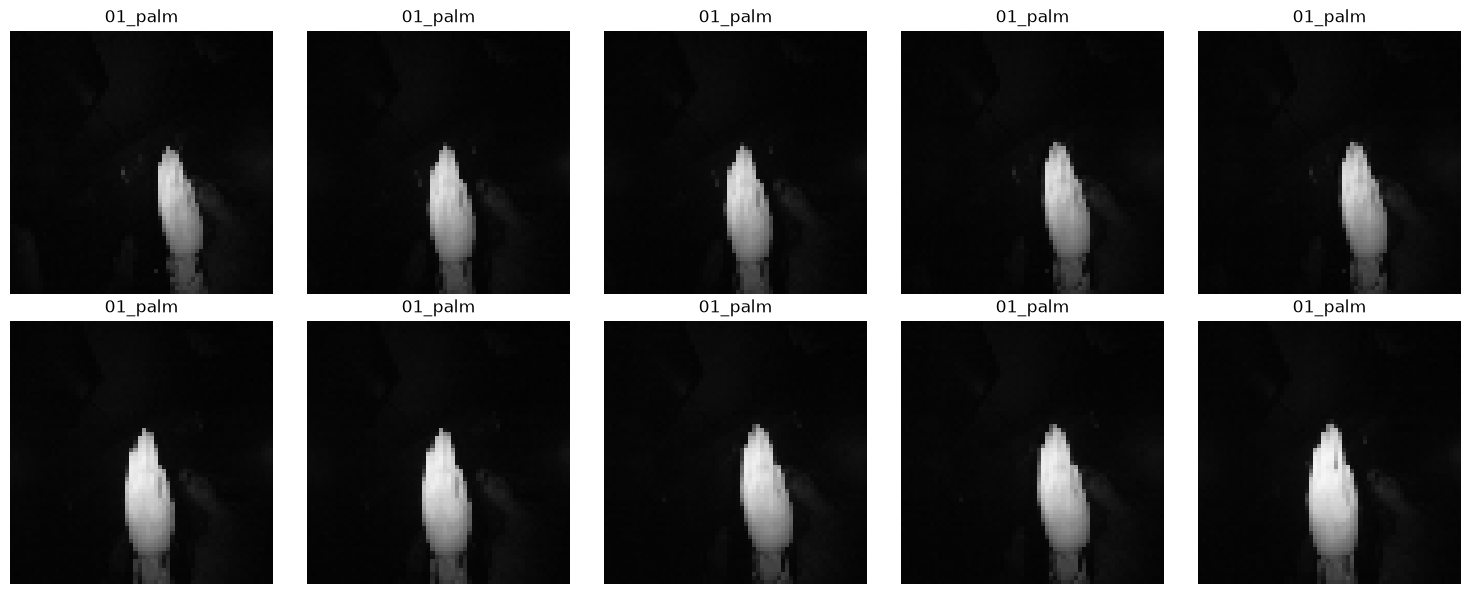

In [6]:
# Display 10 sample images
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    plt.title(gesture_folders[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (16000, 64, 64, 3)
Testing Images: (4000, 64, 64, 3)
Training Labels: (16000,)
Testing Labels: (4000,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    # First Convolution Block
    Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Second Convolution Block
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Third Convolution Block
    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Convert feature maps into a vector
    Flatten(),

    # Fully Connected Layer
    Dense(256, activation="relu"),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation="softmax")
])

c:\Users\Vishesh\Desktop\Internship\PRODIGY_ML_04\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,618 (4.87 MB)

 Trainable params: 1,276,170 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_hand_gesture_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [11]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

TensorFlow Version: 2.21.0
Available GPUs: []


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,618 (4.87 MB)

 Trainable params: 1,276,170 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_hand_gesture_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8954 - loss: 0.3761 - val_accuracy: 0.5100 - val_loss: 4.0395
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9855 - loss: 0.0507 - val_accuracy: 0.9991 - val_loss: 0.0028
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9843 - loss: 0.0497 - val_accuracy: 0.9975 - val_loss: 0.0062
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9860 - loss: 0.0506 - val_accuracy: 0.9966 - val_loss: 0.0081
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9939 - loss: 0.0186 - val_accuracy: 0.9987 - val_loss: 0.0023
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9956 - loss: 0.0182 - val_accuracy: 0.9937 - val_loss: 0.0195
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9920 - loss: 0.0302 - val_accuracy: 0.9984 - val_loss: 0.0056
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9944 - loss: 0.0256 - 

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9977 - loss: 0.0079
Test Loss: 0.0079
Test Accuracy: 99.77%


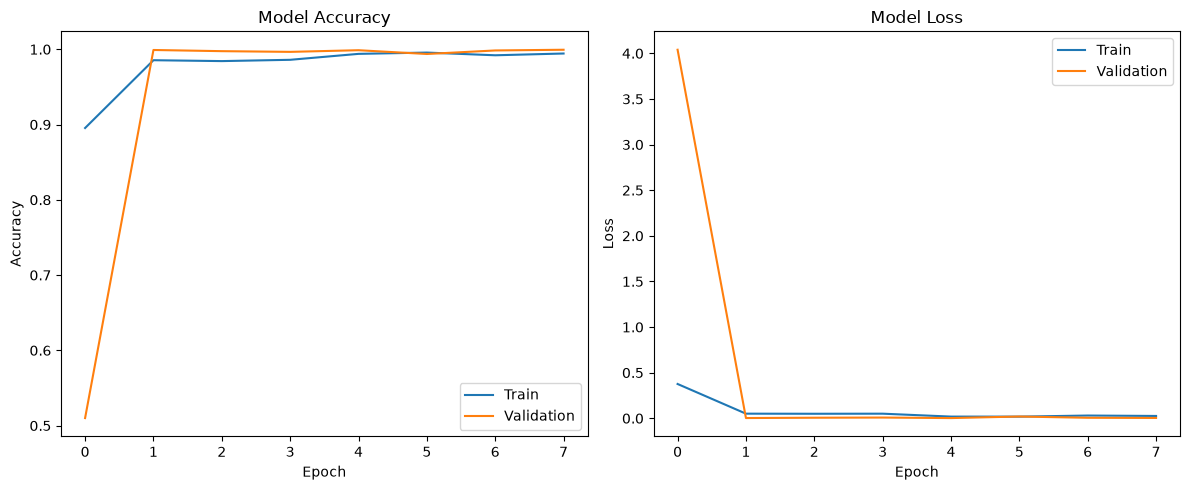

In [15]:
plt.figure(figsize=(12,5))

# Accuracy

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig("accuracy_loss.png", dpi=300)

plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


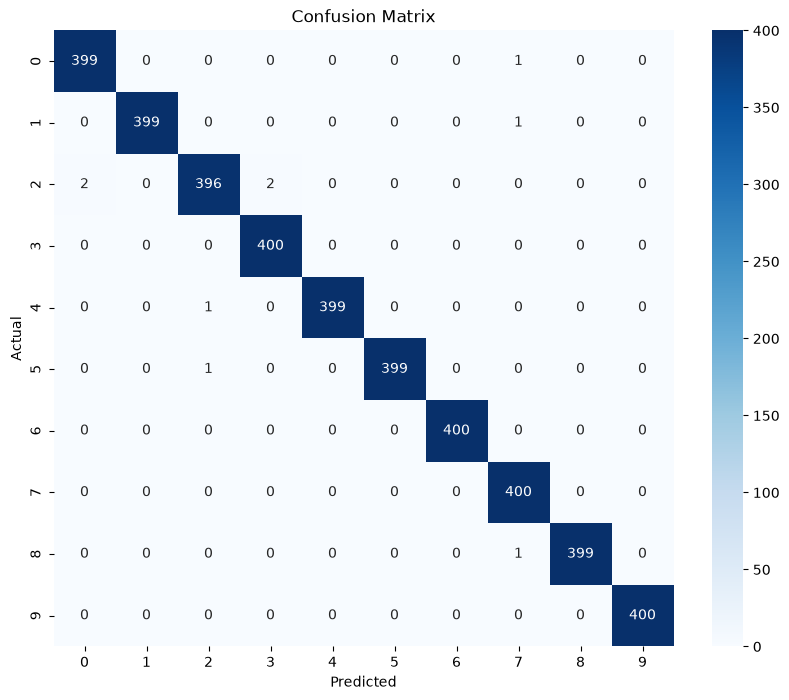

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=gesture_folders
))

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       0.99      0.99      0.99       400
04_fist_moved       0.99      1.00      1.00       400
     05_thumb       1.00      0.99      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [ ]:
model.save("hand_gesture_cnn.keras")
print("Model saved successfully!")

Model saved successfully!


In [17]:
print(y_test.shape)
print(y_test[:10])

(4000,)
[6 2 5 0 9 7 3 1 6 9]


In [18]:
print(y_test.shape)
print(y_pred.shape)
print(np.unique(y_test))

(4000,)
(4000, 10)
[0 1 2 3 4 5 6 7 8 9]


In [20]:
print(gesture_folders)

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [21]:
from tensorflow.keras.models import load_model

# Load first model
model1 = load_model("best_hand_gesture_model.keras")

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Best Model Accuracy :", acc1)
print("Best Model Loss :", loss1)

print("--------------------------------")

# Load second model
model2 = load_model("hand_gesture_cnn.keras")

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("CNN Model Accuracy :", acc2)
print("CNN Model Loss :", loss2)

Best Model Accuracy : 0.9987499713897705
Best Model Loss : 0.0068342918530106544
--------------------------------
CNN Model Accuracy : 0.9984999895095825
CNN Model Loss : 0.006346400827169418
